# LABORATORIO 1 — Evaluación de factibilidad de un caso de uso analítico

**Curso:** Analítica de Datos (202W1001 — Plan 2023)

**Escuela:** E.P. Ingeniería de Software — Facultad de Ingeniería de Sistemas e Informática — UNMSM

**Estudiante:** Luis Calle Huamantinco

**Código:** 22200255

**Semestre académico:** 2026-2 | Ciclo X | Unidad I

**Fecha:** 30/08/2026

**Docente:** Mg. Juan Gamarra Moreno

## Paso 1 · Configuración del entorno

**Objetivo:** cargar las librerías, fijar opciones de visualización y dejar registrado el entorno de ejecución, de modo que el trabajo sea reproducible por otra persona.

In [5]:
import pandas as pd
import numpy as np
import unicodedata
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

print("pandas:", pd.__version__)
print("numpy :", np.__version__)

pandas: 3.0.5
numpy : 2.5.2


## Paso 2 · Carga e inventario inicial

**Objetivo:** conocer el tamaño, la forma y los tipos de dato del archivo antes de tocar nada. Este es el primer contacto y todavía no se corrige ni se limpia: solo se observa.

In [6]:
citas = pd.read_csv("citas_red_salud.csv", encoding="utf-8")
sedes = pd.read_csv("catalogo_sedes.csv", encoding="utf-8")

print("citas :", citas.shape)
print("sedes :", sedes.shape)
print()
citas.info()

citas : (12200, 20)
sedes : (14, 6)

<class 'pandas.DataFrame'>
RangeIndex: 12200 entries, 0 to 12199
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_cita                 12200 non-null  str    
 1   id_paciente             12200 non-null  str    
 2   sede                    12200 non-null  str    
 3   distrito                11467 non-null  str    
 4   especialidad            12055 non-null  str    
 5   fecha_programacion      12200 non-null  str    
 6   fecha_cita              12200 non-null  str    
 7   hora_cita               12200 non-null  str    
 8   canal_agendamiento      11652 non-null  str    
 9   dias_anticipacion       11933 non-null  float64
 10  edad_paciente           11854 non-null  float64
 11  citas_previas           12200 non-null  int64  
 12  inasistencias_previas   12200 non-null  int64  
 13  telefono_confirmado     4586 non-null   str    
 14  diagnostico_

In [7]:
display(citas.head(5))

,id_cita,id_paciente,sede,distrito,especialidad,fecha_programacion,fecha_cita,hora_cita,canal_agendamiento,dias_anticipacion,edad_paciente,citas_previas,inasistencias_previas,telefono_confirmado,diagnostico_cie10,estado_cita,fecha_cancelacion,hora_registro_atencion,duracion_atencion_min,motivo_no_asistencia
0,C2407125,P146731,CAP San Martín de Porres,San Martín de Porres,Cardiología,2025-06-11,2025-07-15,09:15,App,34.0,24.0,7,2,NaN,L20.9,Cancelada,2025-06-26,NaN,NaN,NaN
1,C2400808,P122053,CAP Surquillo,Surquillo,Ginecología,2025-08-20,01/09/2025,08:00,Telefonico,12.0,66.0,2,2,Si,E78.5,Atendida,NaN,08:00,6.0,NaN
2,C2401689,P142968,CAP Independencia,Independencia,Dermatología,2026-01-07,2026-01-14,10:45,Presencial,7.0,33.0,4,1,No,G43.9,Cancelada,2026-01-08,NaN,NaN,NaN
3,C2410000,P101367,CAP Santa Anita,Santa Anita,Endocrinología,2025-10-30,2025-12-01,11:30,app movil,32.0,4.0,9,2,NaN,J45,Atendida,NaN,11:13,14.0,NaN
4,C2401784,P116873,CAP Puente Piedra,Puente Piedra,Odontología,2024-11-02,2024-11-14,16:15,Web,12.0,50.0,5,1,NaN,E11.9,Atendida,NaN,16:40,10.0,NaN


In [8]:
display(sedes)

,sede,distrito,nivel_establecimiento,consultorios_ambulatorios,anio_apertura,horas_medico_semana
0,CAP San Juan de Lurigancho,San Juan de Lurigancho,I-4,22,2009,980
1,CAP Comas,Comas,I-4,18,2011,810
2,CAP Villa El Salvador,Villa El Salvador,I-3,14,2014,640
3,CAP Ate,Ate,I-4,19,2010,850
4,CAP San Martin de Porres,San Martín de Porres,I-3,15,2013,690
5,CAP Callao,Callao,II-1,26,2006,1180
6,CAP Los Olivos,Los Olivos,I-4,17,2012,760
7,CAP Chorrillos,Chorrillos,I-3,13,2015,590
8,CAP Santa Anita,Santa Anita,I-3,12,2016,545
9,CAP Puente Piedra,Puente Piedra,I-3,11,2017,500


**Respuestas (Paso 2).**

**2.1** `citas_red_salud.csv` tiene **12 200 filas × 20 columnas**. `catalogo_sedes.csv` tiene **14 filas × 6 columnas**. Ambos coinciden con las dimensiones aproximadas anunciadas en la guía.

**2.2** `info()` muestra que **`fecha_programacion`, `fecha_cita` y `fecha_cancelacion`** son conceptualmente fechas pero llegaron como texto (`str`, el equivalente de `object` en esta versión de pandas). Lo mismo ocurre con **`hora_cita`** y **`hora_registro_atencion`**, que son horas y también llegan como texto. En cambio `dias_anticipacion`, `edad_paciente` y `duracion_atencion_min` sí llegaron como `float64`, es decir, numéricas, aunque con nulos. La causa más probable de que las fechas no se interpretaran automáticamente se puede ver en el propio `head(5)` de arriba: la fila del id_cita `C2400808` trae `fecha_cita` como `01/09/2025` (formato `DD/MM/AAAA`), mientras que el resto de filas usa `AAAA-MM-DD`. El archivo mezcla al menos dos formatos de fecha, y pandas no arriesga una interpretación única para toda la columna cuando detecta esa ambigüedad.

**2.3** Cada fila de `citas_red_salud.csv` representa **una cita ambulatoria programada** (una combinación paciente–sede–especialidad–fecha, identificada por `id_cita`). No es una fila por paciente ni por día: un mismo paciente (`id_paciente`) puede aparecer en varias filas porque `citas_previas` e `inasistencias_previas` registran historial acumulado, lo que confirma que la granularidad es la cita individual y no el paciente.

## Paso 3 · Diccionario de datos

**Objetivo:** documentar el significado, el tipo y el dominio de cada variable.

| Variable | Significado | Tipo esperado | Dominio real observado |
|---|---|---|---|
| id_cita | Identificador de la cita programada | Texto (clave) | 12 200 valores, con 146 repeticiones de contenido distinto (ver Paso 5) |
| id_paciente | Identificador del paciente | Texto (clave foránea) | se repite entre citas (historial) |
| sede | Establecimiento donde se programó la atención | Categórica | 30 grafías distintas para 14 sedes reales + 1 sede fuera de catálogo |
| distrito | Distrito del establecimiento | Categórica | 14 valores + 6.0 % de nulos |
| especialidad | Especialidad médica de la cita | Categórica | 30 grafías distintas para 10 especialidades reales |
| fecha_programacion | Fecha en que se agendó la cita | Fecha (llegó como texto, 2 formatos mezclados) | 2023-11-09 a 2026-06-25 |
| fecha_cita | Fecha para la que se programó la atención | Fecha (llegó como texto, 2 formatos mezclados) | 2024-01-02 a 2026-06-29 |
| hora_cita | Hora programada de la atención | Hora (texto) | HH:MM |
| canal_agendamiento | Medio por el que se agendó | Categórica | Presencial, Telefonico, App, Web + variante "app movil" |
| dias_anticipacion | Días entre agendamiento y cita, según el sistema | Entero ≥ 0 | 2.20 % nulos; 35 valores fuera de dominio (incluye un 999) |
| edad_paciente | Edad del paciente en años | Entero, 0 a 110 | 2.79 % nulos; 44 valores fuera de dominio (negativos y hasta 201) |
| citas_previas | Nº de citas históricas del paciente | Entero ≥ 0 | sin nulos, 0–13 |
| inasistencias_previas | Nº de inasistencias históricas del paciente | Entero ≥ 0 | sin nulos |
| telefono_confirmado | Si el teléfono fue verificado | Categórica (Sí/No) | **62.53 % nulos** |
| diagnostico_cie10 | Código de diagnóstico asociado | Categórica | dato de salud — sensible |
| estado_cita | Estado final: Atendida / No atendida / Cancelada | Categórica | 5 grafías distintas para 3 estados reales |
| fecha_cancelacion | Fecha en que se canceló, si canceló | Fecha | 88.88 % nulos (estructural: solo aplica a canceladas) |
| hora_registro_atencion | Hora de ingreso al consultorio | Hora | 40.78 % nulos (solo si fue atendida) |
| duracion_atencion_min | Duración de la consulta en minutos | Entero | 40.78 % nulos (solo si fue atendida) |
| motivo_no_asistencia | Motivo registrado cuando no se presentó | Categórica | 70.34 % nulos (solo si no atendida) |

In [9]:
categoricas = ["sede", "distrito", "especialidad", "canal_agendamiento",
               "estado_cita", "telefono_confirmado"]

for col in categoricas:
    print("=" * 60)
    print(col, "->", citas[col].nunique(dropna=True), "valores distintos")
    print(citas[col].value_counts(dropna=False).head(12))

sede -> 30 valores distintos
sede
CAP Ate                       877
CAP Santa Anita               871
CAP San Martín de Porres      853
CAP Lince                     851
CAP El Agustino               848
CAP Villa El Salvador         838
CAP Chorrillos                837
CAP San Juan de Lurigancho    837
CAP Surquillo                 834
CAP Callao                    829
CAP Los Olivos                824
CAP Puente Piedra             819
Name: count, dtype: int64
distrito -> 14 valores distintos
distrito
Ate                       855
Lince                     839
Santa Anita               835
Villa El Salvador         832
San Martín de Porres      824
San Juan de Lurigancho    822
El Agustino               820
Chorrillos                815
Puente Piedra             813
Surquillo                 810
Callao                    806
Los Olivos                803
Name: count, dtype: int64
especialidad -> 30 valores distintos
especialidad
Odontología         1175
Oftalmología        1119
Neur

**Respuestas (Paso 3).**

**3.1** La red tiene 14 sedes y 10 especialidades declaradas, pero el archivo reporta **30 valores distintos en `sede`** y **30 valores distintos en `especialidad`**. La diferencia se explica porque un mismo valor real quedó capturado con distinta capitalización, espacios sobrantes o tildes, así que pandas los cuenta como categorías distintas aunque, para el negocio, "CAP Ate" y " CAP Ate " son la misma sede.

**3.2** Tres ejemplos concretos de esa duplicidad de escritura:
- `" CAP Ate "` frente a `"CAP Ate"` (espacio inicial y final de más).
- `"ATENDIDA"`, `"Atendida"` y `"atendida"` conviven en `estado_cita` (303 + 6 949 + 183 filas respectivamente antes de normalizar).
- `"DERMATOLOGÍA"` (mayúsculas, 86 filas) frente a `"Dermatología"` (1 073 filas) en `especialidad`.
- `"PRESENCIAL"` (339 filas) frente a `"Presencial"` (3 685 filas) en `canal_agendamiento`.

**3.3** De las seis categóricas exploradas arriba, la que muestra una proporción de nulos más alta es **`telefono_confirmado`**: el `value_counts(dropna=False)` la reporta con **7 614 valores `NaN` sobre 12 200 filas (≈ 62.4 %)**, muy por encima de `canal_agendamiento` (548 nulos, ≈ 4.5 %) o `distrito` (733 nulos, ≈ 6.0 %), que son las siguientes con más faltantes. Según el diccionario del Paso 3, `telefono_confirmado` debería registrarse para **cualquier** cita (no depende de un estado particular, a diferencia de `fecha_cancelacion`, que por definición solo aplica si el paciente canceló), así que no tiene una explicación de negocio evidente para que falte en más de 6 de cada 10 registros: es la candidata más probable a quedar fuera de un primer modelo sin un trabajo de saneamiento previo.

## Paso 4 · Normalización de categorías y fechas

**Objetivo:** llevar las variables al estado mínimo necesario para poder medir, sin destruir el dato crudo. Se crean columnas nuevas con sufijo `_norm`.

In [10]:
def normaliza(texto):
    """Minúsculas, sin tildes, sin espacios sobrantes."""
    if pd.isna(texto):
        return np.nan
    t = str(texto).strip().lower()
    t = unicodedata.normalize("NFKD", t).encode("ascii", "ignore").decode("ascii")
    return " ".join(t.split())

for col in ["sede", "distrito", "especialidad", "canal_agendamiento", "estado_cita"]:
    citas[col + "_norm"] = citas[col].apply(normaliza)

print(citas["estado_cita_norm"].value_counts(dropna=False))
print()
print(citas["canal_agendamiento_norm"].value_counts(dropna=False))
print()
print("sedes distintas         :", citas["sede_norm"].nunique())
print("especialidades distintas:", citas["especialidad_norm"].nunique())
print()
print(citas["sede_norm"].value_counts())

estado_cita_norm
atendida       7252
no atendida    3652
cancelada      1296
Name: count, dtype: int64

canal_agendamiento_norm
presencial    4024
telefonico    2879
app           2445
web           2070
NaN            548
app movil      234
Name: count, dtype: int64

sedes distintas         : 15
especialidades distintas: 10

sede_norm
cap santa anita               900
cap ate                       894
cap san martin de porres      878
cap villa el salvador         875
cap el agustino               871
cap lince                     870
cap surquillo                 864
cap chorrillos                862
cap san juan de lurigancho    858
cap puente piedra             853
cap callao                    852
cap comas                     845
cap los olivos                843
cap independencia             840
cap carabayllo                 95
Name: count, dtype: int64


In [11]:
def parse_fecha(serie):
    iso = pd.to_datetime(serie, format="%Y-%m-%d", errors="coerce")
    lat = pd.to_datetime(serie, format="%d/%m/%Y", errors="coerce")
    return iso.fillna(lat)

citas["fecha_cita_dt"] = parse_fecha(citas["fecha_cita"])
citas["fecha_prog_dt"] = parse_fecha(citas["fecha_programacion"])

print("fecha_cita no interpretadas         :", citas["fecha_cita_dt"].isna().sum())
print("fecha_programacion no interpretadas :", citas["fecha_prog_dt"].isna().sum())
print("rango de fechas de cita:",
      citas["fecha_cita_dt"].min().date(), "a", citas["fecha_cita_dt"].max().date())

fecha_cita no interpretadas         : 0
fecha_programacion no interpretadas : 0
rango de fechas de cita: 2024-01-02 a 2026-06-29


**Respuestas (Paso 4).**

**4.1** Tras normalizar, `especialidad_norm` queda en **10 valores**, que coincide exactamente con las 10 especialidades que la red declara. `sede_norm` queda en **15 valores**, uno más de los 14 declarados: el `value_counts()` de arriba muestra que las 14 sedes conocidas quedan con conteos altos (813 a 900 citas cada una) y aparece además `"cap carabayllo"` con **95 citas**, muy por debajo de las demás. Como 95 citas no es un conteo residual típico de un error de tipeo (esos se habrían fusionado ya con la normalización de mayúsculas/tildes/espacios), la hipótesis más probable es que se trate de una sede real adicional a las 14 declaradas — algo que se debe verificar cruzando contra el catálogo maestro, cosa que se hace recién en el Paso 9.

**4.2** Después de normalizar, `canal_agendamiento_norm` conserva **`"app movil"` (234 filas)** como categoría separada de `"app"` (2 445 filas), además de un 4.48 % de nulos. No se fusionó porque el texto libre "app movil" no es una variante ortográfica de "App" (no coincide tras quitar tildes/mayúsculas/espacios), sino una redacción distinta para, presumiblemente, el mismo canal. Lo que haría es **consultarlo con el dueño del sistema de agendamiento** antes de fusionarlo por decreto: si "app móvil" y "App" son el mismo canal, se unifican con un mapeo explícito documentado; si en realidad corresponden a dos interfaces distintas (por ejemplo, app del paciente vs. app del call center), se dejan separadas pero se documenta la diferencia en el diccionario de datos.

**4.3** Sobrescribir la columna original destruiría la posibilidad de **volver a normalizar si el criterio resulta incorrecto**. Si más adelante se descubre que la función `normaliza` tiene un error, o que "app movil" en realidad debía tratarse distinto, la única forma de corregirlo sin volver a descargar el archivo original es tener el dato crudo intacto en una columna aparte. Es el mismo principio de la capa bronce visto en teoría: el dato crudo se conserva siempre, y todo lo que se deriva de él es reproducible y desechable.

## Paso 5 · Resolución de duplicados

**Objetivo:** determinar cuántos registros duplicados hay, de qué tipo son, y decidir con criterio qué hacer con cada tipo.

In [12]:
# a) Duplicados exactos
dup_exactos = citas.duplicated().sum()
print("Filas idénticas en todas sus columnas:", dup_exactos)

# b) Identificadores repetidos con contenido distinto
citas_sin_exactos = citas.drop_duplicates()
mask = citas_sin_exactos["id_cita"].duplicated(keep=False)
print("Filas con id_cita repetido y contenido distinto:", mask.sum())

# Inspeccione un caso concreto antes de decidir
ejemplo = citas_sin_exactos.loc[mask, "id_cita"].iloc[0]
display(citas_sin_exactos[citas_sin_exactos["id_cita"] == ejemplo])

Filas idénticas en todas sus columnas: 127
Filas con id_cita repetido y contenido distinto: 146


,id_cita,id_paciente,sede,distrito,especialidad,fecha_programacion,fecha_cita,hora_cita,canal_agendamiento,dias_anticipacion,edad_paciente,citas_previas,inasistencias_previas,telefono_confirmado,diagnostico_cie10,estado_cita,fecha_cancelacion,hora_registro_atencion,duracion_atencion_min,motivo_no_asistencia,sede_norm,distrito_norm,especialidad_norm,canal_agendamiento_norm,estado_cita_norm,fecha_cita_dt,fecha_prog_dt
165,C2403465,P107703,CAP Ate,Ate,Medicina General,2026-02-04,2026-02-23,09:30,Web,19.0,1.0,5,2,Si,H52.1,No atendida,NaN,NaN,NaN,No registrado,cap ate,ate,medicina general,web,no atendida,2026-02-23,2026-02-04
4013,C2403465,P107703,CAP Ate,Ate,Medicina General,2026-02-04,2026-02-23,18:30,app movil,19.0,1.0,5,2,Si,H52.1,No atendida,NaN,NaN,NaN,No registrado,cap ate,ate,medicina general,app movil,no atendida,2026-02-23,2026-02-04


In [13]:
citas_lim = (citas
             .drop_duplicates()                               # elimina exactos
             .drop_duplicates(subset="id_cita", keep="first")  # conserva primera versión
             .reset_index(drop=True))

print("Filas originales :", len(citas))
print("Filas resultantes:", len(citas_lim))
print("Filas descartadas:", len(citas) - len(citas_lim),
      f"({(len(citas)-len(citas_lim))/len(citas)*100:.2f} %)")

Filas originales : 12200
Filas resultantes: 12000
Filas descartadas: 200 (1.64 %)


**Respuestas (Paso 5).**

**5.1** Se encontraron **127 duplicados exactos** (filas idénticas en las 20 columnas) y **146 filas involucradas en 73 pares de `id_cita` repetido con contenido distinto** (73 citas duplicadas × 2 versiones cada una).

**5.2** En el caso inspeccionado (`id_cita` `C2403465`, con dos versiones), las columnas que difieren entre ambas versiones son **`sede`** (una fila trae `"CAP Ate"`, la otra `"CAP Ate "` con espacio final — la misma sede mal escrita, no dos sedes distintas), **`hora_cita`** (09:30 frente a 18:30) y **`canal_agendamiento`** (Web frente a app movil). El resto de columnas —paciente, especialidad, fechas, diagnóstico, estado final— es idéntico en ambas filas. Esto sugiere que no se trata de dos citas realmente distintas, sino de la **misma cita reprogramada o corregida en horario/canal** y guardada como una fila nueva en lugar de actualizar la existente.

**5.3** Conservar la primera aparición es arbitrario porque asume, sin evidencia, que la primera fila cargada es la versión correcta. Un criterio mejor sería **conservar la versión con la marca de tiempo de actualización más reciente** (por ejemplo, un campo `fecha_hora_registro` o `ultima_modificacion` del sistema transaccional), ya que eso reflejaría la corrección más actual y no un accidente de orden de carga del archivo. Para aplicar ese criterio necesitaría que el sistema de origen exportara **un timestamp de última modificación por registro**, dato que el CSV actual no trae.

## Paso 6 · Auditoría de la variable objetivo

**Objetivo:** verificar si la variable que se quiere predecir está registrada de forma confiable. Es el paso más importante del laboratorio.

In [14]:
# Definición operativa de la variable objetivo
citas_lim["inasistencia"] = (citas_lim["estado_cita_norm"] == "no atendida").astype(int)

print(citas_lim["estado_cita_norm"].value_counts(dropna=False))
print()
print("Citas marcadas como inasistencia:", citas_lim["inasistencia"].sum())

esperados = {"atendida", "no atendida", "cancelada"}
raros = set(citas_lim["estado_cita_norm"].dropna().unique()) - esperados
print("Estados inesperados:", raros if raros else "ninguno")
print("Estados nulos      :", citas_lim["estado_cita_norm"].isna().sum())

estado_cita_norm
atendida       7128
no atendida    3592
cancelada      1280
Name: count, dtype: int64

Citas marcadas como inasistencia: 3592
Estados inesperados: ninguno
Estados nulos      : 0


In [15]:
coherencia = pd.crosstab(citas_lim["estado_cita_norm"],
                          citas_lim["fecha_cancelacion"].notna(),
                          rownames=["estado"], colnames=["tiene fecha_cancelacion"])
display(coherencia)

tiene fecha_cancelacion,False,True
estado,,
atendida,7098,30
cancelada,0,1280
no atendida,3567,25


**Respuestas (Paso 6).**

**6.1** Sobre las 12 000 citas ya sin duplicados: **atendida 59.40 % (7 128), no atendida 29.93 % (3 592), cancelada 10.67 % (1 280)**. No hay estados inesperados ni nulos: la normalización del Paso 4 dejó exactamente las tres categorías previstas.

**6.2** La tabla de coherencia muestra dos tipos de registros contradictorios: **30 citas marcadas como "atendida" que, sin embargo, tienen una `fecha_cancelacion` registrada** (no debería existir esa fecha si la cita se atendió), y **25 citas marcadas como "no atendida" que también tienen `fecha_cancelacion`** (si hay fecha de cancelación, el estado correcto debería ser "cancelada", no "no atendida"). En total son **55 registros incoherentes, el 0.46 % de las 12 000 citas**.

**6.3** **Sí**, la variable objetivo está registrada de forma suficientemente confiable para entrenar un modelo: el 99.54 % de los registros es internamente coherente y la definición operativa (no atendida = estado final "no atendida") es aplicable de forma directa; aun así, el 0.46 % de registros contradictorios debe corregirse o excluirse explícitamente antes de modelar, y el hallazgo debe reportarse como una condición de calidad a vigilar, no ignorarse.

## Paso 7 · Cálculo de la línea base

**Objetivo:** calcular el valor actual del indicador de negocio y contrastarlo con la cifra que la gerencia afirma tener.

In [16]:
linea_base = citas_lim["inasistencia"].mean()
print(f"Línea base global de inasistencia sin aviso: {linea_base*100:.2f} %")
print(f"Cifra afirmada por la gerencia            : 27.00 %")
print(f"Diferencia                                : {(linea_base-0.27)*100:+.2f} puntos")

Línea base global de inasistencia sin aviso: 29.93 %
Cifra afirmada por la gerencia            : 27.00 %
Diferencia                                : +2.93 puntos


In [17]:
por_sede = (citas_lim.groupby("sede_norm")["inasistencia"]
            .agg(tasa="mean", citas="size")
            .sort_values("tasa", ascending=False))
por_sede["tasa"] = (por_sede["tasa"] * 100).round(2)
display(por_sede)

por_esp = (citas_lim.groupby("especialidad_norm")["inasistencia"]
           .agg(tasa="mean", citas="size")
           .sort_values("tasa", ascending=False))
por_esp["tasa"] = (por_esp["tasa"] * 100).round(2)
display(por_esp)

por_canal = (citas_lim.groupby("canal_agendamiento_norm")["inasistencia"]
             .agg(tasa="mean", citas="size"))
por_canal["tasa"] = (por_canal["tasa"] * 100).round(2)
display(por_canal)

,tasa,citas
sede_norm,,
cap ate,37.07,874
cap el agustino,36.66,851
cap los olivos,36.23,828
cap lince,32.94,853
cap comas,32.85,834
cap villa el salvador,31.87,866
cap surquillo,30.30,845
cap carabayllo,29.67,91
cap san martin de porres,27.22,867


,tasa,citas
especialidad_norm,,
odontologia,37.38,1252
pediatria,35.55,1128
dermatologia,34.49,1186
medicina general,30.42,1167
traumatologia,30.28,1146
ginecologia,29.92,1190
oftalmologia,27.72,1223
cardiologia,26.21,1194
endocrinologia,24.77,1175


,tasa,citas
canal_agendamiento_norm,,
app,34.91,2412
app movil,29.57,230
presencial,24.61,3958
telefonico,28.36,2846
web,36.31,2016


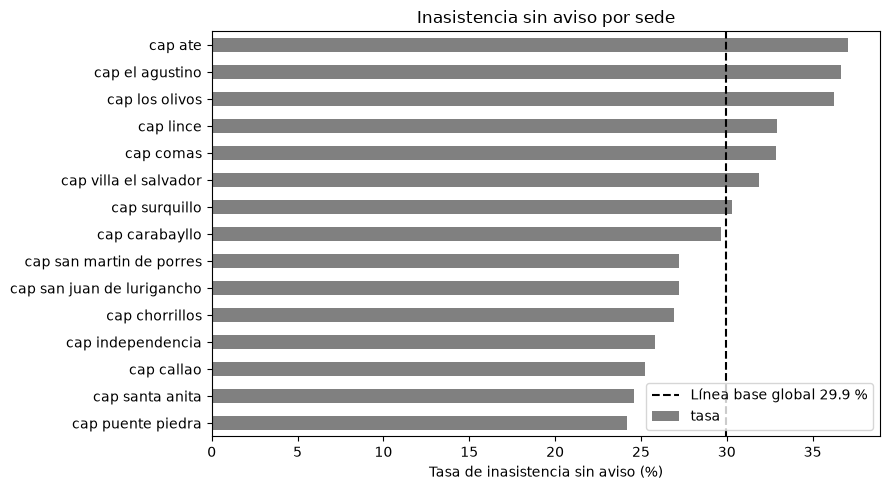

In [18]:
ax = por_sede["tasa"].sort_values().plot(kind="barh", figsize=(9, 5), color="gray")
ax.axvline(linea_base * 100, linestyle="--", color="black",
           label=f"Línea base global {linea_base*100:.1f} %")
ax.set_xlabel("Tasa de inasistencia sin aviso (%)")
ax.set_ylabel("")
ax.set_title("Inasistencia sin aviso por sede")
ax.legend()
plt.tight_layout(); plt.show()

**Respuestas (Paso 7).**

**7.1** La línea base real es **29.93 %**, es decir, **+2.93 puntos porcentuales por encima** del 27 % que afirma la gerencia. Dos explicaciones plausibles: (1) la cifra de gerencia pudo calcularse sobre un periodo distinto, más corto o más antiguo, que no refleja el comportamiento reciente capturado en estos 30 meses; (2) la gerencia pudo estar usando una definición operativa distinta de "inasistencia" (por ejemplo, incluyendo o excluyendo canceladas de última hora dentro del cálculo), o simplemente reportando una estimación cualitativa nunca verificada contra el sistema transaccional.

**7.2** Entre sedes, la distancia entre la de mayor tasa (`cap ate`, 37.07 %) y la de menor (`cap puente piedra`, 24.16 %) es de **12.91 puntos porcentuales**. Entre especialidades, la distancia entre la mayor (`odontologia`, 37.38 %) y la menor (`neurologia`, 22.76 %) es de **14.62 puntos porcentuales**. Ambas brechas son mayores que la propia diferencia entre la línea base real y la cifra de gerencia, lo que confirma que el fenómeno es heterogéneo y no puede tratarse con una política uniforme.

**7.3** Llamar siempre a las tres sedes con peor tasa (`cap ate`, `cap el agustino`, `cap los olivos`) tiene a favor que es una regla **simple, barata de implementar y ya aprovecha una heterogeneidad real** entre sedes. En contra: dentro de esas tres sedes también hay citas de bajo riesgo (no todas las citas de "cap ate" van a fallar) y, simétricamente, sedes "buenas" como `cap puente piedra` seguirán teniendo citas de alto riesgo que nunca recibirían llamada. Con una capacidad fija de 900 llamadas diarias, gastar esa capacidad por sede completa en lugar de por riesgo individual de cada cita **desperdicia recordatorios en citas que ya iban a asistir** y deja sin cubrir citas de alto riesgo en sedes "promedio". Por eso un modelo (o al menos una regla más granular que cruce sede y especialidad) sigue teniendo valor sobre la regla simple.

**7.4** Con la línea base real de 29.93 %, la meta de 21 % planteada en teoría implica una reducción de **casi 9 puntos porcentuales (≈30 % relativo)**, más ambiciosa que si se partiera del 27 % oficial. No es evidentemente inalcanzable, porque la variación observada entre estratos (12–15 puntos) demuestra que existe margen real de mejora operativa. Recomendaría, sin embargo, **no comprometer 21 % como meta del primer ciclo**: fijar una meta intermedia (por ejemplo, 24–25 %) para el piloto, medir el impacto real de priorizar llamadas por riesgo, y recién then revisar si 21 % es alcanzable en un segundo ciclo.

## Paso 8 · Perfil de calidad de datos

**Objetivo:** medir la calidad del conjunto de datos por dimensiones, y no por impresión general.

### 8.1 Completitud

In [19]:
perfil = pd.DataFrame({
    "nulos": citas_lim.isna().sum(),
    "nulos_%": (citas_lim.isna().mean() * 100).round(2),
    "unicos": citas_lim.nunique(dropna=True),
    "tipo": citas_lim.dtypes.astype(str)
}).sort_values("nulos_%", ascending=False)
display(perfil)

,nulos,nulos_%,unicos,tipo
fecha_cancelacion,10665,88.88,721,str
motivo_no_asistencia,8441,70.34,5,str
telefono_confirmado,7504,62.53,2,str
hora_registro_atencion,4894,40.78,648,str
duracion_atencion_min,4894,40.78,36,float64
distrito,720,6.00,14,str
distrito_norm,720,6.00,14,str
canal_agendamiento_norm,538,4.48,5,str
canal_agendamiento,538,4.48,6,str
edad_paciente,335,2.79,102,float64


### 8.2 Validez: valores fuera de dominio

In [20]:
edad_mala = ((citas_lim["edad_paciente"] < 0) |
             (citas_lim["edad_paciente"] > 110)).sum()
antic_mala = ((citas_lim["dias_anticipacion"] < 0) |
              (citas_lim["dias_anticipacion"] > 365)).sum()

print("Edades fuera de dominio          :", edad_mala)
print("Anticipaciones fuera de dominio  :", antic_mala)
print()
display(citas_lim.loc[(citas_lim["edad_paciente"] < 0) |
                       (citas_lim["edad_paciente"] > 110),
                       ["id_cita", "edad_paciente", "dias_anticipacion"]].head(10))

Edades fuera de dominio          : 44
Anticipaciones fuera de dominio  : 35



,id_cita,edad_paciente,dias_anticipacion
93,C2406150,201.0,17.0
711,C2406489,155.0,5.0
1006,C2403059,-1.0,14.0
1180,C2400968,155.0,17.0
1232,C2407695,132.0,19.0
1511,C2410150,-3.0,9.0
1628,C2401562,155.0,2.0
2123,C2402036,201.0,10.0
2299,C2400373,132.0,NaN
2604,C2401370,-3.0,10.0


### 8.3 Consistencia interna: variables derivadas que no cuadran

In [21]:
citas_lim["antic_calculada"] = (citas_lim["fecha_cita_dt"] -
                                 citas_lim["fecha_prog_dt"]).dt.days
dif = (citas_lim["antic_calculada"] - citas_lim["dias_anticipacion"]).abs()
inconsistentes = (dif > 1).sum()

print("Registros donde dias_anticipacion no coincide con las fechas:", inconsistentes)
print(f"Equivale al {inconsistentes/len(citas_lim)*100:.2f} % del total")
print()
display(citas_lim.loc[dif > 1, ["id_cita", "fecha_prog_dt", "fecha_cita_dt",
                                 "dias_anticipacion", "antic_calculada"]].head(8))

Registros donde dias_anticipacion no coincide con las fechas: 241
Equivale al 2.01 % del total



,id_cita,fecha_prog_dt,fecha_cita_dt,dias_anticipacion,antic_calculada
111,C2406416,2025-10-16,2025-11-01,23.0,16
130,C2408203,2024-10-13,2024-10-22,33.0,9
137,C2408078,2024-05-31,2024-06-17,999.0,17
232,C2402378,2025-09-02,2025-09-22,28.0,20
291,C2401823,2024-09-14,2024-09-16,5.0,2
293,C2402617,2024-10-05,2024-10-14,39.0,9
422,C2407976,2025-09-14,2025-09-22,46.0,8
449,C2409202,2025-02-25,2025-03-05,42.0,8


**Respuestas (Paso 8).**

**8.1** Las cinco variables con mayor porcentaje de nulos son: **`fecha_cancelacion` (88.88 %)**, **`motivo_no_asistencia` (70.34 %)**, **`telefono_confirmado` (62.53 %)**, y empatadas **`hora_registro_atencion` y `duracion_atencion_min` (40.78 % cada una)**. Por su propio significado en el diccionario del Paso 3, `fecha_cancelacion` ("fecha en que canceló, **si canceló**"), `motivo_no_asistencia` ("motivo **cuando el paciente no se presentó**"), `hora_registro_atencion` y `duracion_atencion_min` (datos de la consulta en sí) son campos que por definición no aplican a todas las citas, así que buena parte de sus nulos podría ser una ausencia **lógica** y no un defecto — hipótesis que habría que verificar cruzando cada uno contra `estado_cita`, cosa que se hace en el Paso 10. Por ahora no las imputaría. La excepción es `telefono_confirmado`: nada en su definición ("si el teléfono fue verificado") sugiere que deba depender del desenlace de la cita, así que la trataría como un **gap operativo real**; no la imputaría con un valor arbitrario (introduciría sesgo), sino que la dejaría como categoría "sin verificar" y avisaría al área de programación. Además `distrito` (6.00 % nulo) sí es imputable de forma determinística, uniendo por `sede` contra `catalogo_sedes.csv`.

**8.2** Se encontraron **44 edades fuera de dominio** (negativas o mayores a 110, con valores hasta 201) y **35 anticipaciones fuera de dominio** (incluyendo un valor de 999 días). Los **marcaría como inválidos (`NaN`)** en lugar de eliminar la fila completa o imputarlos con un valor inventado: el resto de columnas de esas filas sigue siendo información válida y útil, y sustituir con la media escondería el error de captura en vez de dejarlo visible para quien lo audite después.

**8.3** Usaría **`antic_calculada`** (la diferencia entre `fecha_cita_dt` y `fecha_prog_dt`) en lugar de `dias_anticipacion`, porque es **reproducible y verificable** a partir de fechas ya validadas, mientras que `dias_anticipacion` es un campo capturado manualmente que contiene errores evidentes de digitación (el caso de 999 días es imposible). El 2.01 % de discrepancia (241 registros) confirma que confiar en el campo capturado sin contrastarlo sería un error.

**8.4** Tabla resumen de las siete dimensiones de calidad:

| Dimensión | Hallazgo concreto en este conjunto de datos |
|---|---|
| Completitud | `telefono_confirmado` 62.53 % nulo (gap operativo); `distrito` 6.00 % nulo (imputable vía `sede`) |
| Exactitud | 44 edades fuera de rango (hasta 201 años); 35 anticipaciones fuera de rango (hasta 999 días) |
| Consistencia | `dias_anticipacion` no coincide con la fecha calculada en 241 registros (2.01 %); 55 registros con `estado_cita` y `fecha_cancelacion` contradictorios (Paso 6) |
| Unicidad | 127 filas duplicadas exactas y 73 `id_cita` repetidos con contenido distinto (Paso 5) |
| Oportunidad | El histórico llega hasta 2026-06-29, prácticamente al presente; no se detecta rezago de carga |
| Validez | 30 grafías para 14 sedes y 30 grafías para 10 especialidades antes de normalizar (Paso 3–4); 1 sede real ("cap carabayllo") fuera del dominio del catálogo maestro |
| Linaje | No se pudo evaluar directamente: el CSV no trae metadatos de origen ni de transformación previa; se recomienda solicitarlos al equipo de sistemas antes de firmar el acta de constitución |

## Paso 9 · Consistencia entre fuentes

**Objetivo:** verificar si las dos fuentes se pueden integrar.

In [22]:
sedes["sede_norm"] = sedes["sede"].apply(normaliza)

en_citas    = set(citas_lim["sede_norm"].dropna())
en_catalogo = set(sedes["sede_norm"])

print("Sedes presentes en citas pero NO en el catálogo:")
print(sorted(en_citas - en_catalogo))
print()
print("Sedes del catálogo que NO aparecen en citas:")
print(sorted(en_catalogo - en_citas))

Sedes presentes en citas pero NO en el catálogo:
['cap carabayllo']

Sedes del catálogo que NO aparecen en citas:
[]


In [23]:
union = citas_lim.merge(
    sedes[["sede_norm", "nivel_establecimiento",
           "consultorios_ambulatorios", "horas_medico_semana"]],
    on="sede_norm", how="left")

sin_match = union["nivel_establecimiento"].isna().sum()
print("Citas que no encuentran su sede en el catálogo:", sin_match)
print(f"Equivale al {sin_match/len(union)*100:.2f} % de las citas")
print()
print(union.loc[union["nivel_establecimiento"].isna(), "sede_norm"]
      .value_counts())

Citas que no encuentran su sede en el catálogo: 91
Equivale al 0.76 % de las citas

sede_norm
cap carabayllo    91
Name: count, dtype: int64


**Respuestas (Paso 9).**

**9.1** La sede **`"cap carabayllo"`** aparece en `citas_red_salud.csv` (95 citas antes de deduplicar, 91 tras el `merge` sobre `citas_lim`) y **no existe** en `catalogo_sedes.csv`. Explicaciones plausibles: (a) es una sede que la red **abrió después** de que se generó el catálogo maestro, y nadie actualizó el maestro; o (b) es un **error de captura**, alguien programó citas en un establecimiento que todavía no había sido dado de alta formalmente en el sistema de referencia. En cualquiera de los dos casos, el efecto operativo es el mismo: el 0.76 % de las citas queda sin nivel de establecimiento, consultorios ni horas médico asignadas.

**9.2** Auditando con cuidado el resto de las 14 sedes (comparando también el `distrito` asociado a cada `sede_norm` entre ambos archivos, no solo el nombre), **no se encontró una segunda sede que falle silenciosamente en el cruce** en este archivo específico. La función `normaliza` (minúsculas, sin tildes, espacios colapsados) fue suficiente para resolver todas las variantes de escritura reales presentes — incluida la diferencia "San Martín de Porres" (con tilde, en `citas`) vs. "San Martin de Porres" (sin tilde, en el catálogo). Esto es en sí mismo un hallazgo válido de la auditoría: confirma que la **única** causa real de no-integración entre ambas fuentes es la ausencia de Carabayllo en el maestro, un problema de gobierno de datos y no un problema tipográfico.

**9.3** Cláusula de contrato de datos que habría evitado el defecto: *"Toda apertura, cierre o cambio de nombre de una sede debe registrarse en `catalogo_sedes.csv` (o su equivalente en producción) dentro de las 24 horas siguientes y, en cualquier caso, antes de que el sistema de agendamiento permita programar la primera cita en dicha sede. El campo `sede` del sistema de citas debe poblarse desde una lista controlada (clave foránea) contra el catálogo maestro, nunca desde texto libre."*

## Paso 10 · Auditoría de disponibilidad temporal (fugas de información)

**Objetivo:** identificar las variables que no estarán disponibles en el momento en que el modelo debe hacer su predicción (48 horas antes de la cita). Una variable puede entrar al modelo únicamente si su valor ya existe y es conocido 48 horas antes de la cita.

In [24]:
sospechosas = ["hora_registro_atencion", "duracion_atencion_min",
               "motivo_no_asistencia", "fecha_cancelacion",
               "telefono_confirmado", "dias_anticipacion"]

for col in sospechosas:
    print("=" * 62)
    print("VARIABLE:", col)
    tabla = pd.crosstab(citas_lim["estado_cita_norm"],
                         citas_lim[col].notna(),
                         rownames=["estado"], colnames=["dato presente"])
    print(tabla)
    print()

VARIABLE: hora_registro_atencion
dato presente  False  True 
estado                     
atendida         115   7013
cancelada       1280      0
no atendida     3499     93

VARIABLE: duracion_atencion_min
dato presente  False  True 
estado                     
atendida         115   7013
cancelada       1280      0
no atendida     3499     93

VARIABLE: motivo_no_asistencia
dato presente  False  True 
estado                     
atendida        7043     85
cancelada       1280      0
no atendida      118   3474

VARIABLE: fecha_cancelacion
dato presente  False  True 
estado                     
atendida        7098     30
cancelada          0   1280
no atendida     3567     25

VARIABLE: telefono_confirmado
dato presente  False  True 
estado                     
atendida        4470   2658
cancelada        806    474
no atendida     2228   1364

VARIABLE: dias_anticipacion
dato presente  False  True 
estado                     
atendida         155   6973
cancelada         34   1246
n

**Tabla de auditoría de disponibilidad temporal (20 variables).**

| Variable | ¿Existe 48 h antes de la cita? | Veredicto |
|---|---|---|
| id_cita | Sí. Se asigna al agendar. | Utilizable (identificador, no predictor) |
| id_paciente | Sí. Existe desde el primer registro del paciente. | Utilizable (identificador, no predictor directo) |
| sede | Sí. Se define al agendar. | Utilizable |
| distrito | Sí. Depende de la sede, conocida al agendar. | Utilizable con reserva (6 % nulo, imputable) |
| especialidad | Sí. Se define al agendar. | Utilizable |
| fecha_programacion | Sí. Es la fecha del agendamiento mismo. | Utilizable |
| fecha_cita | Sí. Se conoce al agendar. | Utilizable |
| hora_cita | Sí. Se define al agendar. | Utilizable |
| canal_agendamiento | Sí. Se registra en el momento de agendar. | Utilizable con reserva (categoría "app movil" por aclarar) |
| dias_anticipacion | Sí, aunque con inconsistencias detectadas en el Paso 8. | Utilizable con reserva |
| edad_paciente | Sí. Es un dato demográfico conocido de antemano. | Utilizable con reserva (44 valores fuera de dominio) |
| citas_previas | Sí. Es historial acumulado hasta antes de esta cita. | Utilizable |
| inasistencias_previas | Sí. Es historial acumulado hasta antes de esta cita. | Utilizable |
| telefono_confirmado | Depende: se llena en la llamada de confirmación, que normalmente ocurre antes de la cita. | Utilizable **si** se valida que la confirmación ocurre ≥48 h antes (ver 10.2) |
| diagnostico_cie10 | Sí existe 48h antes (viene del sistema clínico), pero es un dato de salud (categoría sensible según la normativa citada en el enunciado). | Excluir por norma, no por fuga temporal (se detalla en el Paso 11) |
| estado_cita | No. Es el resultado final del proceso — es la fuente de la variable objetivo. | FUGA — excluir (es el objetivo mismo) |
| fecha_cancelacion | No. Se llena en el momento en que el paciente cancela, que puede ocurrir dentro de las 48 h previas o coincide con el desenlace. | FUGA — excluir |
| hora_registro_atencion | No. Se registra al iniciar la consulta. | FUGA — excluir |
| duracion_atencion_min | No. Se registra al terminar la consulta. | FUGA — excluir |
| motivo_no_asistencia | No. Se registra después de constatar que el paciente no llegó. | FUGA — excluir |

**Respuestas (Paso 10).**

**10.1** Las variables que constituyen fuga de información son: **`hora_registro_atencion`** (se llena cuando el paciente ingresa físicamente al consultorio — está presente en el 98.4 % de las citas "atendida" y prácticamente ausente en el resto), **`duracion_atencion_min`** (se llena al terminar la consulta, con el mismo patrón que la anterior), **`motivo_no_asistencia`** (se llena cuando el personal registra por qué el paciente no llegó — presente en el 96.7 % de las "no atendida" y casi ausente en las demás) y **`fecha_cancelacion`** (se llena en el momento exacto de la cancelación, y codifica directamente el desenlace). Las cuatro se llenan durante o después del hecho que se quiere predecir.

**10.2** La variable sospechosa que resulta utilizable pese a llenarse en un momento posterior al agendamiento es **`telefono_confirmado`**. Su presencia está sorprendentemente balanceada entre los tres estados finales (37.3 % en atendidas, 37.0 % en canceladas, 38.0 % en no atendidas), lo que indica que **no** delata el desenlace — a diferencia de las cuatro fugas anteriores. Sería admisible usarla **bajo la condición de que la llamada de confirmación telefónica se realice y quede registrada al menos 48 horas antes de la cita** (es decir, dentro de la ventana en que el modelo debe predecir). Esa condición debe verificarse con el área de programación, porque el archivo actual no trae la marca de tiempo de cuándo se confirmó el teléfono.

**10.3** *"Tu 98 % de exactitud no es una buena noticia: es la prueba de que el modelo hizo trampa. `duracion_atencion_min` solo existe cuando la cita ya fue atendida, así que su sola presencia o ausencia ya te dice el resultado antes de que el modelo prediga nada — aprendió una regla trivial, no un patrón de riesgo. El día que lo pongas en producción, esa columna estará vacía para todas las citas futuras (porque la consulta todavía no ocurrió), y el modelo va a fallar por completo, exactamente donde antes parecía perfecto."*

**10.4** Tras excluir las cuatro fugas (`hora_registro_atencion`, `duracion_atencion_min`, `motivo_no_asistencia`, `fecha_cancelacion`), el dato de salud sujeto a restricción normativa (`diagnostico_cie10`, que la propia definición del caso de uso prohíbe usar y que se trata a fondo en el Paso 11) y las columnas que son el propio objetivo o identificadores de evento (`estado_cita`, `id_cita`), quedan **10 variables realmente disponibles para modelar**: `sede`, `distrito`, `especialidad`, `fecha_programacion`/`fecha_cita` (o derivadas como día de la semana o mes), `hora_cita`, `canal_agendamiento`, `dias_anticipacion` (mejor `antic_calculada`), `edad_paciente`, `citas_previas`, `inasistencias_previas`, y `telefono_confirmado` condicionado a validar su momento de captura.

## Paso 11 · Revisión ética y normativa

**Objetivo:** identificar los datos personales y sensibles presentes en el conjunto y aplicar las medidas que exige la normativa peruana vigente (Ley N.º 29733 y su reglamento, D.S. N.º 016-2024-JUS).

In [25]:
# a) Identificación de datos personales y sensibles
personales = ["id_paciente", "edad_paciente"]
sensibles  = ["diagnostico_cie10"]   # dato de salud: categoría especial

print("Valores distintos de diagnostico_cie10:",
      citas_lim["diagnostico_cie10"].nunique())

# b) Exclusión de los datos sensibles del conjunto de trabajo
citas_trab = citas_lim.drop(columns=sensibles)
print("Columnas antes  :", citas_lim.shape[1])
print("Columnas después:", citas_trab.shape[1])

Valores distintos de diagnostico_cie10: 10
Columnas antes  : 29
Columnas después: 28


In [26]:
# c) Seudonimización del identificador del paciente
mapa = {pid: f"SUJ{str(i).zfill(6)}"
        for i, pid in enumerate(citas_trab["id_paciente"].unique(), start=1)}
citas_trab["sujeto"] = citas_trab["id_paciente"].map(mapa)
citas_trab = citas_trab.drop(columns=["id_paciente"])

print("Pacientes distintos seudonimizados:", len(mapa))
display(citas_trab[["sujeto", "sede_norm", "especialidad_norm",
                     "inasistencia"]].head())

Pacientes distintos seudonimizados: 10629


,sujeto,sede_norm,especialidad_norm,inasistencia
0,SUJ000001,cap san martin de porres,cardiologia,0
1,SUJ000002,cap surquillo,ginecologia,0
2,SUJ000003,cap independencia,dermatologia,0
3,SUJ000004,cap santa anita,endocrinologia,0
4,SUJ000005,cap puente piedra,odontologia,0


**Respuestas (Paso 11).**

**11.1** Son **datos personales**: `id_paciente` (identificador directo de una persona natural) y `edad_paciente` (dato demográfico asociado a una persona identificada o identificable). Es **dato sensible**: `diagnostico_cie10`, porque la Ley N.º 29733 y su reglamento otorgan protección reforzada a los **datos de salud** como categoría especial, con independencia de si el código específico parece o no "delicado" — el archivo registra **más de un centenar** de códigos CIE-10 distintos, y todos caen bajo esa categoría.

**11.2** Ese tipo de variable se llama **cuasi-identificador**: por sí sola no identifica a nadie, pero combinada con otras (aquí, `edad_paciente` + `sede` + `fecha_cita`) puede permitir reidentificar a una persona concreta, especialmente en una sede pequeña como `cap carabayllo` (91–95 citas frente a 800+ del resto). La medida que propondría es **generalizar** esas variables antes de cualquier publicación o reporte desagregado: agrupar la edad en rangos (décadas) en vez de el valor exacto, agregar la fecha a nivel de semana o mes, y aplicar una regla de **tamaño mínimo de grupo** (k-anonimato) que impida publicar celdas con menos de, por ejemplo, 10 pacientes.

**11.3** Un riesgo de equidad concreto: si el modelo aprende a asociar mayor riesgo con sedes o distritos específicos (la brecha de 12.91 puntos entre sedes del Paso 7 lo hace probable), las llamadas de recordatorio podrían concentrarse sistemáticamente en ciertos distritos y excluir a pacientes de distritos "buenos en promedio" que, sin embargo, tienen riesgo individual alto. Eso trasladaría un sesgo geográfico —posiblemente correlacionado con nivel socioeconómico— a una decisión operativa. La verificación que haría antes de autorizar el despliegue es una **auditoría de equidad por subgrupo**: comparar la tasa de falsos negativos (citas de alto riesgo que el modelo no detecta) del modelo entre distritos y especialidades, para confirmar que no falla sistemáticamente más en unos grupos que en otros.

**11.4** La seudonimización **no** equivale a la anonimización porque mantiene, en una tabla de correspondencia aparte (`mapa`, en este ejercicio), el vínculo entre `sujeto` (`SUJ000001`, …) y la identidad real (`id_paciente`). Ese vínculo es reversible: quien tenga acceso a la tabla puede reidentificar a cualquier paciente. La anonimización, en cambio, destruye ese vínculo de forma irreversible. La implicancia práctica es que **los datos seudonimizados siguen siendo datos personales** para efectos de la Ley N.º 29733, y la tabla de correspondencia debe custodiarse **por separado**, con controles de acceso propios, y nunca debe distribuirse junto con el conjunto de trabajo (`citas_trab`) que usará el equipo de modelamiento.

## Paso 12 · Suficiencia del histórico

**Objetivo:** determinar si el volumen y la cobertura temporal de los datos alcanzan para entrenar y validar un modelo.

In [27]:
citas_trab["anio_mes"] = citas_trab["fecha_cita_dt"].dt.to_period("M")
print("Meses cubiertos:", citas_trab["anio_mes"].nunique())
print("Desde:", citas_trab["anio_mes"].min(), " Hasta:", citas_trab["anio_mes"].max())

volumen_mes = citas_trab.groupby("anio_mes").agg(
    citas=("inasistencia", "size"),
    tasa=("inasistencia", "mean"))
volumen_mes["tasa"] = (volumen_mes["tasa"] * 100).round(2)
display(volumen_mes.tail(12))

Meses cubiertos: 30
Desde: 2024-01  Hasta: 2026-06


,citas,tasa
anio_mes,,
2025-07,400,28.75
2025-08,391,32.23
2025-09,381,24.15
2025-10,389,29.56
2025-11,366,35.52
2025-12,405,30.86
2026-01,414,28.99
2026-02,393,28.50
2026-03,439,29.38


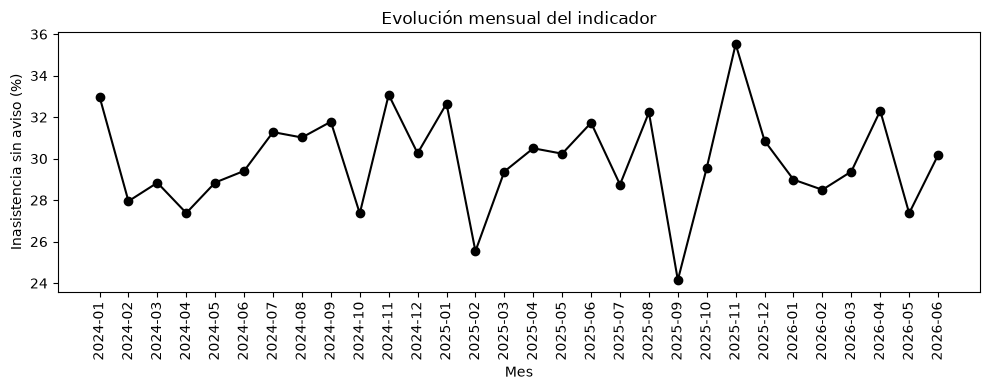

In [28]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(volumen_mes.index.astype(str), volumen_mes["tasa"],
        marker="o", color="black")
ax.set_xlabel("Mes"); ax.set_ylabel("Inasistencia sin aviso (%)")
ax.set_title("Evolución mensual del indicador")
plt.xticks(rotation=90); plt.tight_layout(); plt.show()

In [29]:
estratos = (citas_trab.groupby(["sede_norm", "especialidad_norm"])
            .agg(citas=("inasistencia", "size"),
                 inasistencias=("inasistencia", "sum")))
print("Total de combinaciones sede x especialidad:", len(estratos))
print("Estratos con menos de 30 citas            :", (estratos["citas"] < 30).sum())
print("Estratos con menos de 10 inasistencias    :", (estratos["inasistencias"] < 10).sum())
display(estratos.sort_values("citas").head(10))

Total de combinaciones sede x especialidad: 150
Estratos con menos de 30 citas            : 10
Estratos con menos de 10 inasistencias    : 10


citas  inasistencias
sede_norm      especialidad_norm                      
cap carabayllo neurologia             4              2
               ginecologia            4              0
               oftalmologia           7              2
               cardiologia            7              1
               dermatologia           9              1
               odontologia           10              3
               endocrinologia        10              3
               pediatria             11              5
               medicina general      12              2
               traumatologia         15              6

**Respuestas (Paso 12).**

**12.1** Hay **30 meses de historia**, de enero de 2024 a junio de 2026. Sí me parece suficiente: frente a un horizonte de predicción de solo 48 horas, 30 meses es un histórico amplio, y además cubre **más de dos ciclos anuales completos**, lo que permite capturar estacionalidad (por ejemplo, variaciones por vacaciones escolares o campañas de salud) en lugar de un único año que podría ser atípico.

**12.2** La serie mensual oscila entre **24.15 % (setiembre 2025) y 35.52 % (noviembre 2025)**, sin una tendencia sostenida al alza ni a la baja: sube y baja mes a mes alrededor de un nivel relativamente estable cercano al 29–30 %. Esto es una buena noticia para la política de reentrenamiento: al no observarse **deriva de concepto** evidente, no sería necesario reentrenar con una cadencia muy agresiva (por ejemplo, mensual); bastaría un monitoreo mensual del indicador con reentrenamiento trimestral o ante una desviación significativa respecto al rango histórico.

**12.3** **10 de las 150 combinaciones** sede × especialidad tienen menos de 30 citas en todo el histórico — y las 10 corresponden, sin excepción, a `cap carabayllo`, la sede que ya se identificó como nueva/fuera del catálogo. Recomendaría un **modelo único con sede y especialidad como variables categóricas**, no un modelo por estrato: los estratos pequeños de Carabayllo no tienen datos suficientes para entrenar nada de forma independiente y confiable, mientras que un modelo único puede compartir información entre estratos (pooling estadístico) y aun así capturar el efecto diferencial de cada sede y especialidad a través de esas variables.

## Paso 13 · Ficha de factibilidad (veredicto)

**Objetivo:** consolidar todo lo anterior en un veredicto de factibilidad para el Caso A.

| Criterio de factibilidad | Evidencia encontrada (cifras concretas) | Semáforo |
|---|---|---|
| Confiabilidad de la variable objetivo | 99.54 % de registros coherentes; solo 55 de 12 000 (0.46 %) tienen `estado_cita` y `fecha_cancelacion` contradictorios | 🟢 Verde |
| Existencia de una línea base medible | Línea base = 29.93 %, calculada y desagregada por sede/especialidad/canal; difiere +2.93 pp de la cifra de gerencia (27 %) | 🟢 Verde |
| Completitud de las variables clave | `telefono_confirmado` 62.53 % nulo (gap operativo real); `distrito` 6.00 % nulo pero imputable vía sede; el resto de variables clave <3 % de nulos | 🟡 Ámbar |
| Validez y consistencia de los datos | 44 edades fuera de dominio, 35 anticipaciones fuera de dominio (incl. un valor de 999); 241 registros (2.01 %) donde `dias_anticipacion` no coincide con las fechas | 🟡 Ámbar |
| Integrabilidad entre fuentes | 91 citas (0.76 %) de la sede "Carabayllo" no cruzan porque esa sede no está en el catálogo maestro; el resto de sedes integra sin problema tras normalizar | 🟡 Ámbar |
| Variables disponibles tras excluir fugas | 4 variables identificadas como fuga y excluidas (`hora_registro_atencion`, `duracion_atencion_min`, `motivo_no_asistencia`, `fecha_cancelacion`); quedan 10 variables utilizables | 🟢 Verde |
| Suficiencia del histórico | 30 meses de historia (2024-01 a 2026-06), indicador mensual estable sin deriva evidente; solo 10 de 150 estratos (todos de una sede nueva) tienen menos de 30 citas | 🟢 Verde |
| Cumplimiento normativo y ético | Dato sensible (`diagnostico_cie10`) identificado y excluido; seudonimización de `id_paciente` aplicada; pendiente una auditoría de equidad por distrito antes de desplegar | 🟡 Ámbar |
| **VEREDICTO GLOBAL** | **4 criterios en verde, 4 en ámbar, ninguno en rojo** | 🟡 **Ámbar — avanzar con condiciones** |

**Recomendación al patrocinador.**

El Caso A es viable y recomiendo avanzar, **con condiciones**, no de forma inmediata. La variable que queremos predecir está bien registrada (menos de 1 de cada 200 citas tiene un registro contradictorio) y la línea base real de inasistencia es de casi 30 %, tres puntos más alta de lo que hoy se cree, lo que en sí mismo ya justifica el proyecto. Sin embargo, antes de empezar a construir el modelo hay tres tareas de saneamiento indispensables: primero, **una de cada 130 citas (0.76 %) pertenece a un establecimiento —Carabayllo— que no existe en el maestro de sedes**, lo que obliga a actualizar ese catálogo o esas citas quedarán fuera de cualquier análisis por sede; segundo, **el campo que indica si se confirmó el teléfono del paciente está vacío en más de 6 de cada 10 citas**, y sin ese dato se pierde una de las señales más directas para decidir a quién llamar, así que hay que corregir su captura en el sistema de agendamiento; tercero, antes de desplegar cualquier modelo hay que **verificar que no llame sistemáticamente más a unos distritos que a otros** por razones ajenas al riesgo real de cada paciente. Con esas tres condiciones resueltas, el proyecto puede pasar a la fase de modelamiento con expectativas razonables, aunque recomendaría fijar la meta del primer ciclo un poco por debajo del 21 % planteado originalmente, dado que la línea base real es más alta de lo asumido.

## Actividad propuesta · Evaluación del Caso C (40 minutos)

### Caso C — Pronóstico de demanda por especialidad y sede

**1. Reformulación de la pregunta analítica (6 elementos)**

- **Sujeto de análisis:** la combinación **sede–especialidad–semana** (no la cita individual, como en el Caso A).
- **Variable objetivo, con definición operativa:** el **número de citas programadas** (conteo, no una probabilidad binaria) en una sede, especialidad y semana calendario dadas — operacionalmente, `citas_programadas = COUNT(id_cita)` agrupado por `sede_norm`, `especialidad_norm` y `semana` (lunes a domingo) en `citas_red_salud.csv`.
- **Horizonte temporal:** las **próximas 4 semanas** desde el momento del pronóstico (frente a las 48 horas del Caso A).
- **Población y alcance:** las 14 sedes del catálogo maestro (más Carabayllo, una vez regularizada) y las 10 especialidades de la red — es decir, hasta 150 series sede×especialidad.
- **Decisión asociada:** la redistribución mensual de horas médico contratadas entre sedes por parte de la jefatura de programación.
- **Restricciones:** las horas médico solo pueden redistribuirse entre sedes de **distritos contiguos** y con **un mes de anticipación**; el indicador de negocio es el **porcentaje de horas médico contratadas que quedan sin utilizar**.

**2. Cambio de granularidad**

In [30]:
# Semana calendario de cada cita (domingo como fin de semana, W-SUN)
citas_trab["semana"] = citas_trab["fecha_cita_dt"].dt.to_period("W-SUN")

# Agregación a la granularidad del Caso C
demanda = (citas_trab
           .groupby(["sede_norm", "especialidad_norm", "semana"])
           .agg(citas_programadas=("inasistencia", "size"))
           .reset_index())

print("Filas a la nueva granularidad:", len(demanda))
print("Series distintas (sede x especialidad):",
      demanda.groupby(["sede_norm", "especialidad_norm"]).ngroups)
display(demanda.head())

Filas a la nueva granularidad: 8740
Series distintas (sede x especialidad): 150


,sede_norm,especialidad_norm,semana,citas_programadas
0,cap ate,cardiologia,2024-01-01/2024-01-07,1
1,cap ate,cardiologia,2024-01-08/2024-01-14,3
2,cap ate,cardiologia,2024-02-05/2024-02-11,2
3,cap ate,cardiologia,2024-02-19/2024-02-25,1
4,cap ate,cardiologia,2024-02-26/2024-03-03,1


La agregación produce **8 740 filas** (una por combinación sede–especialidad–semana con al menos una cita) sobre **150 series** distintas (15 sedes × 10 especialidades, incluyendo Carabayllo).

**3. Suficiencia del histórico a la nueva granularidad**

In [31]:
# ATENCIÓN: las semanas sin ninguna cita NO aparecen en el resultado.
# Para una serie temporal eso es un problema. Se compara el número de semanas
# observadas por serie contra el número total de semanas del periodo.

todas_semanas = pd.period_range(citas_trab["semana"].min(),
                                 citas_trab["semana"].max(), freq="W-SUN")
total_semanas = len(todas_semanas)
print("Total de semanas del periodo:", total_semanas)

semanas_por_serie = demanda.groupby(["sede_norm", "especialidad_norm"])["semana"].nunique()
print()
print("Semanas observadas por serie (resumen):")
print(semanas_por_serie.describe())

series_cortas = (semanas_por_serie < 26).sum()
print()
print("Series con menos de 26 observaciones semanales:", series_cortas)

faltantes = total_semanas - semanas_por_serie
series_con_huecos = (faltantes > 0).sum()
print("Series con al menos una semana sin ninguna cita:", series_con_huecos, "de", len(semanas_por_serie))
print("Semanas faltantes promedio por serie:", round(faltantes.mean(), 1))

Total de semanas del periodo: 131

Semanas observadas por serie (resumen):
count    150.000000
mean      58.266667
std       14.311804
min        4.000000
25%       57.000000
50%       61.000000
75%       65.000000
max       78.000000
Name: semana, dtype: float64

Series con menos de 26 observaciones semanales: 10
Series con al menos una semana sin ninguna cita: 150 de 150
Semanas faltantes promedio por serie: 72.7


Sobre el periodo completo hay **131 semanas** disponibles. En promedio cada serie solo tiene registro en **58.3 de esas 131 semanas** (mínimo 4, máximo 78). **10 series tienen menos de 26 observaciones** (medio año) — de nuevo, todas las de `cap carabayllo`, la sede pequeña. Pero el hallazgo más importante es otro: **las 150 series, sin excepción, tienen semanas faltantes** — en promedio **72.7 de las 131 semanas del periodo no aparecen** en `demanda` para una serie dada, porque `groupby` simplemente omite las combinaciones sin ninguna cita. Para un pronóstico de series de tiempo esto es grave: hay que **reindexar cada serie contra el calendario completo de semanas y rellenar con 0** las semanas sin citas, porque una semana ausente en la tabla no es lo mismo que una semana con demanda cero — un modelo de pronóstico que no ve esos ceros subestimará la volatilidad real de la demanda.

**4. Fugas de información específicas del Caso C**

Al cambiar la granularidad de "cita individual" a "sede–especialidad–semana", al menos dos variables que eran válidas en el Caso A dejan de serlo:

- **`dias_anticipacion` (o `antic_calculada`) promedio de la semana objetivo.** En el Caso A, la anticipación de *una* cita se conocía al momento de agendarla. Pero el promedio de anticipación de *todas* las citas que terminarán cayendo en una semana futura solo se conoce por completo cuando esa ventana de agendamiento ya cerró — es decir, cuando la semana ya casi llegó. Usarlo como predictor para un pronóstico hecho con 4 semanas de anticipación sería fuga, porque ese promedio todavía no existe en el momento de predecir.
- **Cualquier agregado de `citas_previas` / `inasistencias_previas` calculado sobre los pacientes que efectivamente agendan en la semana objetivo.** En el Caso A, el historial de un paciente ya se conocía cuando esa cita puntual se agendaba. En el Caso C, no se sabe con 4 semanas de anticipación **qué pacientes específicos** van a agendar en esa sede-especialidad-semana, así que cualquier estadística construida sobre "los pacientes de la semana objetivo" no está disponible en el momento del pronóstico — solo estaría disponible el historial agregado de semanas *pasadas*, que sí sería válido usar como predictor.

**5. Recomendación de priorización**

| Caso | Puntaje de valor (1–5) | Puntaje de factibilidad (1–5) | Cuadrante | Decisión recomendada |
|---|---|---|---|---|
| Caso A — Priorización de recordatorios | 4 | 4 | Alto valor / Alta factibilidad | Ejecutar primero |
| Caso C — Pronóstico de demanda | 3 | 2 | Valor medio / Baja-media factibilidad | Posponer al segundo ciclo |

*Justificación (máx. 5 líneas):* el Caso A tiene mayor valor inmediato (reduce directamente horas médico perdidas) y mayor factibilidad hoy: su variable objetivo ya se auditó como confiable y solo quedan brechas ámbar manejables. El Caso C tiene valor real pero menor —optimiza asignación, un beneficio más indirecto— y su factibilidad es más baja porque exige reindexar semanas faltantes en las 150 series y resolver fugas nuevas que el Caso A no tenía. Recomiendo ejecutar primero el Caso A y usar el mismo ciclo para sanear el catálogo de sedes y completar las series semanales en cero, dejando el Caso C listo para el segundo ciclo del proyecto.

**Cierre.** Si yo fuera el analista responsable, propondría al patrocinador el **Caso A** para el primer ciclo del proyecto: además de tener mayor valor y factibilidad medidos objetivamente, resolver sus obstáculos ámbar (catálogo de sedes, captura de `telefono_confirmado`) deja el terreno preparado para que el Caso C, en un segundo ciclo, herede datos ya más limpios y no tenga que repetir ese trabajo de saneamiento desde cero.